In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Generate reference trajectory
time_s = np.arange(0, 300, 1)
dt = 1.0

true_x_m = 0.8 * time_s
true_y_m = 20 * np.sin(0.03 * time_s) + 0.05 * time_s

df = pd.DataFrame({
    "time_s": time_s,
    "true_x_m": true_x_m,
    "true_y_m": true_y_m
})

df.head()

,time_s,true_x_m,true_y_m
0,0,0.0,0.000000
1,1,0.8,0.649910
2,2,1.6,1.299280
3,3,2.4,1.947571
4,4,3.2,2.594244


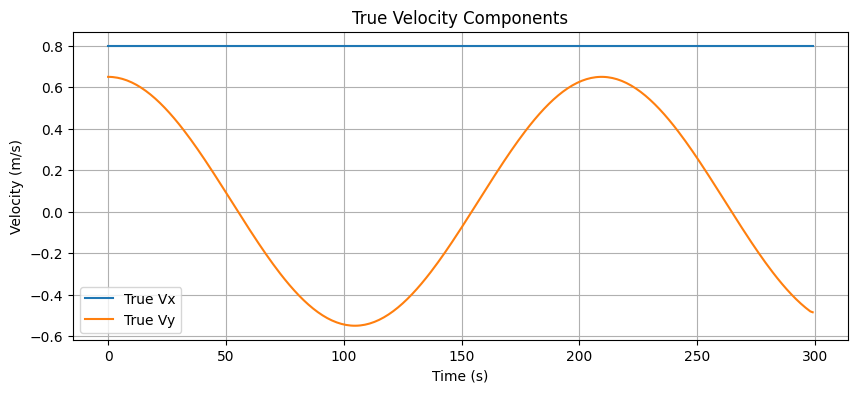

In [3]:
# Compute true velocity components
df["true_vx_mps"] = np.gradient(df["true_x_m"], dt)
df["true_vy_mps"] = np.gradient(df["true_y_m"], dt)

plt.figure(figsize=(10, 4))
plt.plot(df["time_s"], df["true_vx_mps"], label="True Vx")
plt.plot(df["time_s"], df["true_vy_mps"], label="True Vy")
plt.title("True Velocity Components")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Simulate GNSS degraded measurements
np.random.seed(42)

noise_x = np.random.normal(0, 2.0, len(df))
noise_y = np.random.normal(0, 2.0, len(df))

multipath_bias_x = 4.0 * np.sin(0.05 * df["time_s"])
multipath_bias_y = 3.0 * np.cos(0.04 * df["time_s"])

urban_noise_x = np.random.normal(0, 4.0, len(df))
urban_noise_y = np.random.normal(0, 4.0, len(df))
urban_bias_x = 5.0 * np.sin(0.08 * df["time_s"])
urban_bias_y = 4.0 * np.cos(0.06 * df["time_s"])

# Start with moderate degradation everywhere
df["gnss_x_m"] = df["true_x_m"] + noise_x + 0.5 * multipath_bias_x
df["gnss_y_m"] = df["true_y_m"] + noise_y + 0.5 * multipath_bias_y

# Urban-like severe degradation interval
urban_mask = (df["time_s"] >= 200) & (df["time_s"] <= 260)
df.loc[urban_mask, "gnss_x_m"] = (
    df.loc[urban_mask, "true_x_m"]
    + urban_noise_x[urban_mask]
    + urban_bias_x[urban_mask]
)
df.loc[urban_mask, "gnss_y_m"] = (
    df.loc[urban_mask, "true_y_m"]
    + urban_noise_y[urban_mask]
    + urban_bias_y[urban_mask]
)

# GNSS outage interval
outage_mask = (df["time_s"] >= 120) & (df["time_s"] <= 180)
df.loc[outage_mask, ["gnss_x_m", "gnss_y_m"]] = np.nan

In [5]:
# Simulate INS measurements and dead reckoning
np.random.seed(123)

ins_bias_vx = 0.03
ins_bias_vy = -0.02

ins_noise_vx = np.random.normal(0, 0.15, len(df))
ins_noise_vy = np.random.normal(0, 0.15, len(df))

df["ins_vx_mps"] = df["true_vx_mps"] + ins_bias_vx + ins_noise_vx
df["ins_vy_mps"] = df["true_vy_mps"] + ins_bias_vy + ins_noise_vy

ins_x = [df.loc[0, "true_x_m"]]
ins_y = [df.loc[0, "true_y_m"]]

for i in range(1, len(df)):
    ins_x.append(ins_x[-1] + df.loc[i, "ins_vx_mps"] * dt)
    ins_y.append(ins_y[-1] + df.loc[i, "ins_vy_mps"] * dt)

df["ins_x_m"] = ins_x
df["ins_y_m"] = ins_y

In [6]:
def position_error(true_x, true_y, x, y):
    return np.sqrt((x - true_x)**2 + (y - true_y)**2)

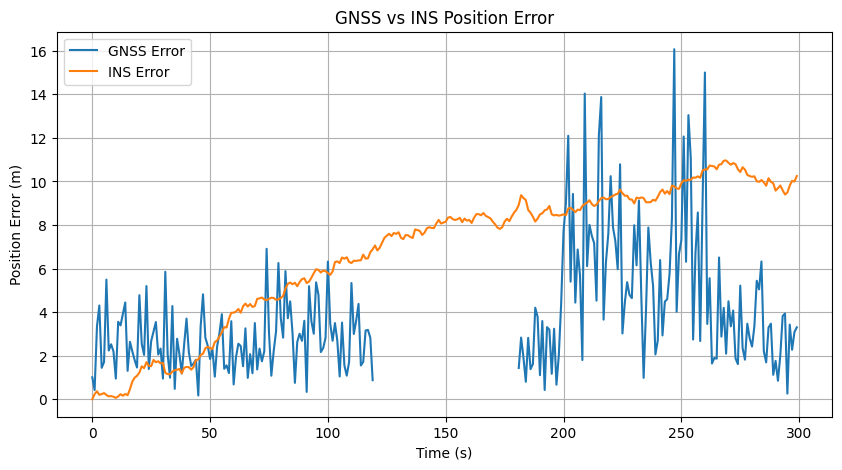

In [7]:
df["error_gnss_m"] = position_error(
    df["true_x_m"], df["true_y_m"], df["gnss_x_m"], df["gnss_y_m"]
)

df["error_ins_m"] = position_error(
    df["true_x_m"], df["true_y_m"], df["ins_x_m"], df["ins_y_m"]
)

plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_gnss_m"], label="GNSS Error")
plt.plot(df["time_s"], df["error_ins_m"], label="INS Error")
plt.title("GNSS vs INS Position Error")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

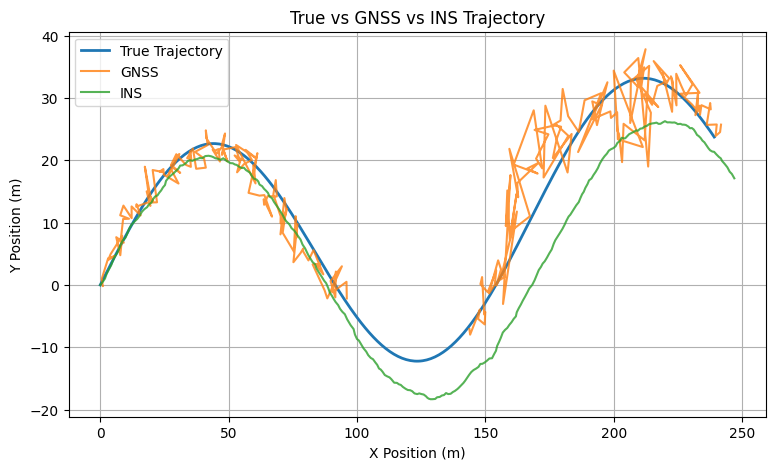

In [8]:
plt.figure(figsize=(9, 5))
plt.plot(df["true_x_m"], df["true_y_m"], label="True Trajectory", linewidth=2)
plt.plot(df["gnss_x_m"], df["gnss_y_m"], label="GNSS", alpha=0.8)
plt.plot(df["ins_x_m"], df["ins_y_m"], label="INS", alpha=0.8)
plt.title("True vs GNSS vs INS Trajectory")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Fixed fusion baseline
fixed_alpha = 0.7  # trust GNSS more when available

fused_x_fixed = []
fused_y_fixed = []

for i in range(len(df)):
    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_fixed.append(ins_x_i)
        fused_y_fixed.append(ins_y_i)
    else:
        fused_x_fixed.append(fixed_alpha * gnss_x + (1 - fixed_alpha) * ins_x_i)
        fused_y_fixed.append(fixed_alpha * gnss_y + (1 - fixed_alpha) * ins_y_i)

df["fused_x_fixed_m"] = fused_x_fixed
df["fused_y_fixed_m"] = fused_y_fixed

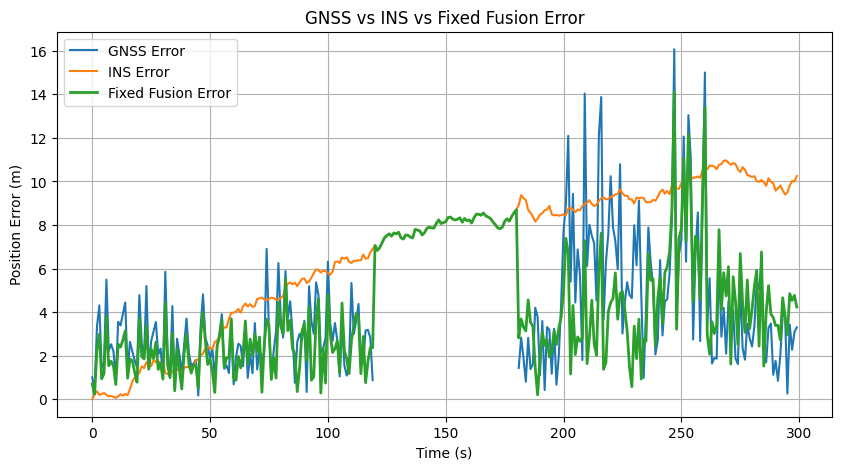

In [10]:
df["error_fused_fixed_m"] = position_error(
    df["true_x_m"], df["true_y_m"], df["fused_x_fixed_m"], df["fused_y_fixed_m"]
)

plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_gnss_m"], label="GNSS Error")
plt.plot(df["time_s"], df["error_ins_m"], label="INS Error")
plt.plot(df["time_s"], df["error_fused_fixed_m"], label="Fixed Fusion Error", linewidth=2)
plt.title("GNSS vs INS vs Fixed Fusion Error")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# For each time step, search for the best alpha from 0 to 1
alpha_candidates = np.linspace(0, 1, 101)
optimal_alpha_list = []

for i in range(len(df)):
    true_x = df.loc[i, "true_x_m"]
    true_y = df.loc[i, "true_y_m"]

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]

    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    # If GNSS is missing, best alpha should be 0 (fully INS)
    if np.isnan(gnss_x) or np.isnan(gnss_y):
        optimal_alpha_list.append(0.0)
        continue

    best_alpha = 0.0
    best_error = np.inf

    for alpha in alpha_candidates:
        fused_x = alpha * gnss_x + (1 - alpha) * ins_x_i
        fused_y = alpha * gnss_y + (1 - alpha) * ins_y_i

        err = np.sqrt((fused_x - true_x)**2 + (fused_y - true_y)**2)

        if err < best_error:
            best_error = err
            best_alpha = alpha

    optimal_alpha_list.append(best_alpha)

df["optimal_alpha"] = optimal_alpha_list
df[["time_s", "optimal_alpha"]].head(15)

,time_s,optimal_alpha
0,0,0.00
1,1,0.35
2,2,0.04
3,3,0.02
4,4,0.14
5,5,0.06
6,6,0.03
7,7,0.04
8,8,0.03
9,9,0.01


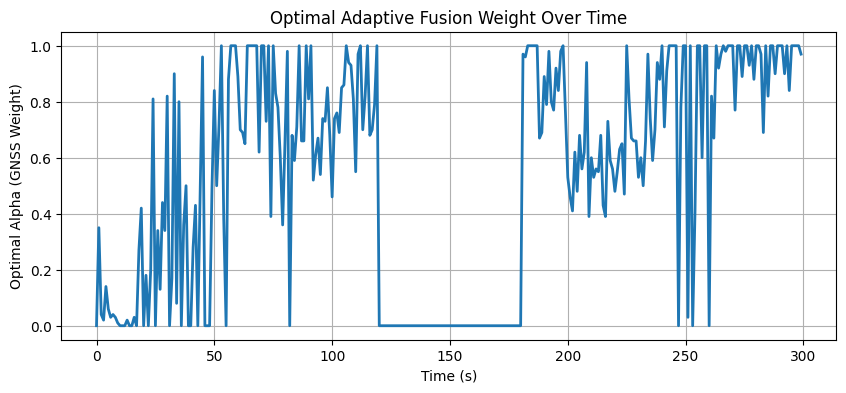

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df["time_s"], df["optimal_alpha"], linewidth=2)
plt.title("Optimal Adaptive Fusion Weight Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Optimal Alpha (GNSS Weight)")
plt.grid(True)
plt.show()

In [13]:
# Feature engineering
df["gnss_available"] = (~df["gnss_x_m"].isna()).astype(int)

df["gnss_ins_diff_x"] = np.abs(df["gnss_x_m"] - df["ins_x_m"])
df["gnss_ins_diff_y"] = np.abs(df["gnss_y_m"] - df["ins_y_m"])

df["gnss_ins_diff_x"] = df["gnss_ins_diff_x"].fillna(999)
df["gnss_ins_diff_y"] = df["gnss_ins_diff_y"].fillna(999)

df["rolling_gnss_std_x"] = df["gnss_x_m"].rolling(window=5, min_periods=1).std()
df["rolling_gnss_std_y"] = df["gnss_y_m"].rolling(window=5, min_periods=1).std()

df["rolling_gnss_std_x"] = df["rolling_gnss_std_x"].fillna(0)
df["rolling_gnss_std_y"] = df["rolling_gnss_std_y"].fillna(0)

df["ins_speed_mps"] = np.sqrt(df["ins_vx_mps"]**2 + df["ins_vy_mps"]**2)

feature_cols = [
    "gnss_available",
    "gnss_ins_diff_x",
    "gnss_ins_diff_y",
    "rolling_gnss_std_x",
    "rolling_gnss_std_y",
    "ins_speed_mps"
]

df[feature_cols + ["optimal_alpha"]].head()

,gnss_available,gnss_ins_diff_x,gnss_ins_diff_y,rolling_gnss_std_x,rolling_gnss_std_y,ins_speed_mps,optimal_alpha
0,1,0.993428,0.157990,0.000000,0.000000,0.999814,0.00
1,1,0.356172,0.523056,0.261628,0.838868,1.102243,0.35
2,1,1.242995,3.253820,1.333077,2.302754,1.020793,0.04
3,1,3.288832,2.903124,2.353918,2.385929,0.939181,0.02
4,1,0.070282,1.674888,2.051513,2.183614,0.957690,0.14


In [14]:
X = df[feature_cols]
y = df["optimal_alpha"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 240
Testing samples: 60


In [15]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse_alpha = np.sqrt(mean_squared_error(y_test, y_pred))
mae_alpha = mean_absolute_error(y_test, y_pred)
r2_alpha = r2_score(y_test, y_pred)

print("Alpha Prediction RMSE:", rmse_alpha)
print("Alpha Prediction MAE:", mae_alpha)
print("Alpha Prediction R^2:", r2_alpha)

Alpha Prediction RMSE: 0.24806364805006212
Alpha Prediction MAE: 0.17697063266799198
Alpha Prediction R^2: 0.5652404739042733


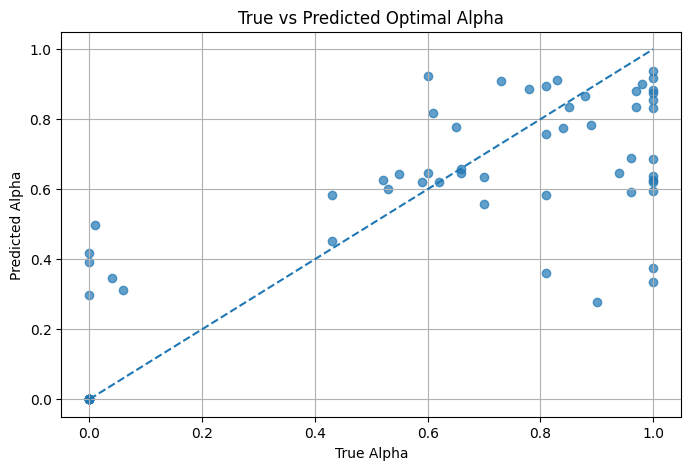

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("True vs Predicted Optimal Alpha")
plt.xlabel("True Alpha")
plt.ylabel("Predicted Alpha")
plt.grid(True)
plt.show()

In [17]:
df["predicted_alpha"] = model.predict(df[feature_cols])
df["predicted_alpha"] = df["predicted_alpha"].clip(0, 1)

In [18]:
fused_x_ai = []
fused_y_ai = []

for i in range(len(df)):
    alpha = df.loc[i, "predicted_alpha"]

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]

    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_ai.append(ins_x_i)
        fused_y_ai.append(ins_y_i)
    else:
        fused_x_ai.append(alpha * gnss_x + (1 - alpha) * ins_x_i)
        fused_y_ai.append(alpha * gnss_y + (1 - alpha) * ins_y_i)

df["fused_x_ai_m"] = fused_x_ai
df["fused_y_ai_m"] = fused_y_ai

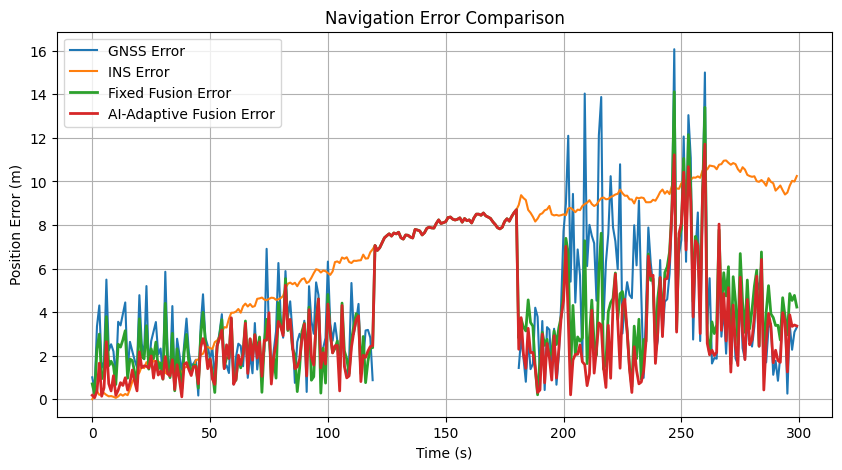

In [19]:
df["error_fused_ai_m"] = position_error(
    df["true_x_m"], df["true_y_m"], df["fused_x_ai_m"], df["fused_y_ai_m"]
)

plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_gnss_m"], label="GNSS Error")
plt.plot(df["time_s"], df["error_ins_m"], label="INS Error")
plt.plot(df["time_s"], df["error_fused_fixed_m"], label="Fixed Fusion Error", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI-Adaptive Fusion Error", linewidth=2)
plt.title("Navigation Error Comparison")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def compute_navigation_metrics(error_series, x_col, y_col):
    return {
        "RMSE_m": np.sqrt(np.nanmean(error_series**2)),
        "MAE_m": np.nanmean(np.abs(error_series)),
        "Availability": np.sum(~np.isnan(x_col) & ~np.isnan(y_col)) / len(error_series)
    }

metrics_gnss = compute_navigation_metrics(df["error_gnss_m"], df["gnss_x_m"], df["gnss_y_m"])
metrics_ins = compute_navigation_metrics(df["error_ins_m"], df["ins_x_m"], df["ins_y_m"])
metrics_fixed = compute_navigation_metrics(df["error_fused_fixed_m"], df["fused_x_fixed_m"], df["fused_y_fixed_m"])
metrics_ai = compute_navigation_metrics(df["error_fused_ai_m"], df["fused_x_ai_m"], df["fused_y_ai_m"])

summary_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_Adaptive_Fusion": metrics_ai
}).T

summary_df

,RMSE_m,MAE_m,Availability
GNSS_Only,4.751649,3.832134,0.796667
INS_Only,7.466007,6.758360,1.000000
Fixed_Fusion,5.040144,4.238612,1.000000
AI_Adaptive_Fusion,4.692186,3.747097,1.000000


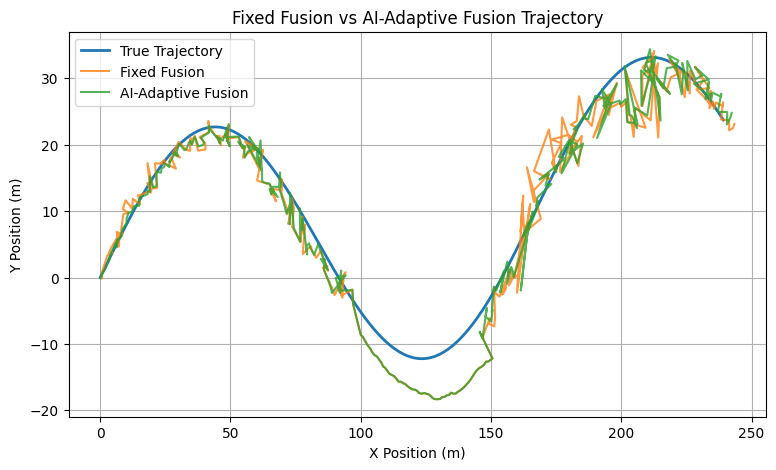

In [21]:
plt.figure(figsize=(9, 5))
plt.plot(df["true_x_m"], df["true_y_m"], label="True Trajectory", linewidth=2)
plt.plot(df["fused_x_fixed_m"], df["fused_y_fixed_m"], label="Fixed Fusion", alpha=0.8)
plt.plot(df["fused_x_ai_m"], df["fused_y_ai_m"], label="AI-Adaptive Fusion", alpha=0.8)
plt.title("Fixed Fusion vs AI-Adaptive Fusion Trajectory")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
2,gnss_ins_diff_y,0.312660
1,gnss_ins_diff_x,0.250344
0,gnss_available,0.143910
3,rolling_gnss_std_x,0.133479
4,rolling_gnss_std_y,0.091505
5,ins_speed_mps,0.068102


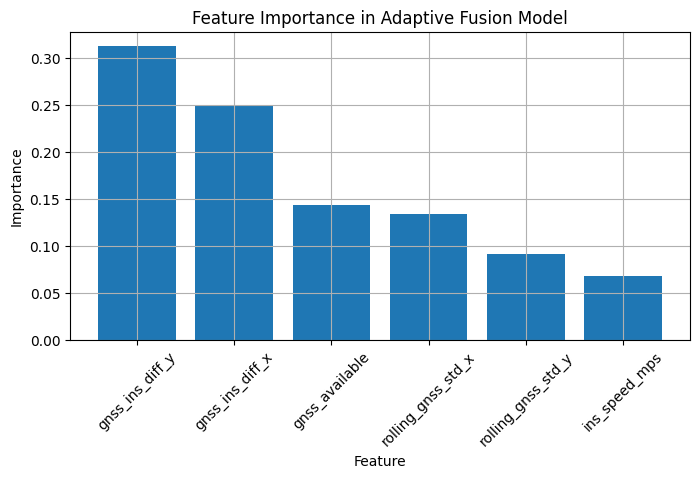

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title("Feature Importance in Adaptive Fusion Model")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [25]:
df.to_csv("ai_adaptive_gnss_ins_results.csv", index=False)
summary_df.to_csv("ai_adaptive_gnss_ins_summary.csv")

print("AI-Adaptive GNSS/INS project results saved successfully.")

AI-Adaptive GNSS/INS project results saved successfully.


In [26]:
summary_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_Adaptive_Fusion,4.6922,3.7471,1.0000


In [27]:
# Scenario labels for each time step
scenario_label = []

for i in range(len(df)):
    t = df.loc[i, "time_s"]
    gnss_available = not (np.isnan(df.loc[i, "gnss_x_m"]) or np.isnan(df.loc[i, "gnss_y_m"]))

    if not gnss_available:
        scenario_label.append("outage")
    elif 200 <= t <= 260:
        scenario_label.append("urban")
    elif 30 <= t <= 110:
        scenario_label.append("noisy")
    else:
        scenario_label.append("nominal")

df["scenario_label"] = scenario_label
df["scenario_label"].value_counts()

,count
scenario_label,
nominal,97
noisy,81
outage,61
urban,61


In [28]:
# Stronger temporal/context features
df["gnss_x_filled"] = df["gnss_x_m"].interpolate().bfill().ffill()
df["gnss_y_filled"] = df["gnss_y_m"].interpolate().bfill().ffill()

df["gnss_dx"] = df["gnss_x_filled"].diff().fillna(0)
df["gnss_dy"] = df["gnss_y_filled"].diff().fillna(0)

df["ins_dx"] = df["ins_x_m"].diff().fillna(0)
df["ins_dy"] = df["ins_y_m"].diff().fillna(0)

df["rolling_gnss_mean_x"] = df["gnss_x_filled"].rolling(window=5, min_periods=1).mean()
df["rolling_gnss_mean_y"] = df["gnss_y_filled"].rolling(window=5, min_periods=1).mean()

df["rolling_gnss_std_x"] = df["gnss_x_filled"].rolling(window=5, min_periods=1).std().fillna(0)
df["rolling_gnss_std_y"] = df["gnss_y_filled"].rolling(window=5, min_periods=1).std().fillna(0)

df["gnss_ins_gap"] = np.sqrt(
    (df["gnss_ins_diff_x"] ** 2) + (df["gnss_ins_diff_y"] ** 2)
)

df[[
    "gnss_dx", "gnss_dy", "ins_dx", "ins_dy",
    "rolling_gnss_mean_x", "rolling_gnss_mean_y",
    "rolling_gnss_std_x", "rolling_gnss_std_y",
    "gnss_ins_gap"
]].head()

,gnss_dx,gnss_dy,ins_dx,ins_dy,rolling_gnss_mean_x,rolling_gnss_mean_y,rolling_gnss_std_x,rolling_gnss_std_y,gnss_ins_gap
0,0.000000,0.000000,0.000000,0.000000,0.993428,-0.157990,0.000000,0.000000,1.005913
1,-0.369999,1.186338,0.979602,0.505292,0.808429,0.435179,0.261628,0.838868,0.632808
2,2.471614,3.260722,0.872447,0.529958,1.570634,1.719809,1.333077,2.302754,3.483157
3,2.649892,0.368455,0.604056,0.719151,2.614209,2.454238,2.353918,2.385929,4.386860
4,-2.615904,-0.624243,0.743210,0.603994,2.717174,2.770047,2.051513,2.183614,1.676362


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

classifier_feature_cols = [
    "gnss_available",
    "gnss_ins_diff_x",
    "gnss_ins_diff_y",
    "gnss_ins_gap",
    "rolling_gnss_std_x",
    "rolling_gnss_std_y",
    "gnss_dx",
    "gnss_dy",
    "ins_speed_mps"
]

X_cls = df[classifier_feature_cols]
y_cls = df["scenario_label"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

clf.fit(X_train_cls, y_train_cls)
y_pred_cls = clf.predict(X_test_cls)

print("Classification Report")
print(classification_report(y_test_cls, y_pred_cls))
print("Confusion Matrix")
print(confusion_matrix(y_test_cls, y_pred_cls))

Classification Report
              precision    recall  f1-score   support

       noisy       0.69      0.69      0.69        16
     nominal       0.76      0.65      0.70        20
      outage       1.00      1.00      1.00        12
       urban       0.80      1.00      0.89        12

    accuracy                           0.80        60
   macro avg       0.81      0.83      0.82        60
weighted avg       0.80      0.80      0.80        60

Confusion Matrix
[[11  4  0  1]
 [ 5 13  0  2]
 [ 0  0 12  0]
 [ 0  0  0 12]]


In [30]:
# Stronger feature set for alpha prediction
regression_feature_cols = [
    "gnss_available",
    "gnss_ins_diff_x",
    "gnss_ins_diff_y",
    "gnss_ins_gap",
    "rolling_gnss_std_x",
    "rolling_gnss_std_y",
    "gnss_dx",
    "gnss_dy",
    "ins_dx",
    "ins_dy",
    "ins_speed_mps"
]

X_reg = df[regression_feature_cols]
y_reg = df["optimal_alpha"]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42, shuffle=True
)

reg_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)

rmse_alpha_new = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
mae_alpha_new = mean_absolute_error(y_test_reg, y_pred_reg)
r2_alpha_new = r2_score(y_test_reg, y_pred_reg)

print("Improved Alpha Prediction RMSE:", rmse_alpha_new)
print("Improved Alpha Prediction MAE:", mae_alpha_new)
print("Improved Alpha Prediction R^2:", r2_alpha_new)

Improved Alpha Prediction RMSE: 0.21569018651599192
Improved Alpha Prediction MAE: 0.13881194438981784
Improved Alpha Prediction R^2: 0.671312168400986


In [31]:
# Predict scenario and alpha for full dataset
df["predicted_scenario"] = clf.predict(df[classifier_feature_cols])

df["predicted_alpha_v2"] = reg_model.predict(df[regression_feature_cols])
df["predicted_alpha_v2"] = df["predicted_alpha_v2"].clip(0, 1)

# Scenario-aware correction rules
adjusted_alpha = []

for i in range(len(df)):
    scenario = df.loc[i, "predicted_scenario"]
    alpha = df.loc[i, "predicted_alpha_v2"]

    if scenario == "outage":
        alpha = 0.0
    elif scenario == "urban":
        alpha = min(alpha, 0.45)   # trust INS more in urban degradation
    elif scenario == "noisy":
        alpha = min(max(alpha, 0.35), 0.75)
    else:  # nominal
        alpha = max(alpha, 0.65)   # trust GNSS more in clean conditions

    adjusted_alpha.append(alpha)

df["adjusted_alpha"] = adjusted_alpha

fused_x_ai_v2 = []
fused_y_ai_v2 = []

for i in range(len(df)):
    alpha = df.loc[i, "adjusted_alpha"]

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_ai_v2.append(ins_x_i)
        fused_y_ai_v2.append(ins_y_i)
    else:
        fused_x_ai_v2.append(alpha * gnss_x + (1 - alpha) * ins_x_i)
        fused_y_ai_v2.append(alpha * gnss_y + (1 - alpha) * ins_y_i)

df["fused_x_ai_v2_m"] = fused_x_ai_v2
df["fused_y_ai_v2_m"] = fused_y_ai_v2

In [32]:
df["error_fused_ai_v2_m"] = position_error(
    df["true_x_m"], df["true_y_m"], df["fused_x_ai_v2_m"], df["fused_y_ai_v2_m"]
)

metrics_ai_v2 = compute_navigation_metrics(
    df["error_fused_ai_v2_m"],
    df["fused_x_ai_v2_m"],
    df["fused_y_ai_v2_m"]
)

summary_v2_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_Adaptive_Fusion_V1": metrics_ai,
    "AI_Scenario_Aware_Fusion_V2": metrics_ai_v2
}).T

summary_v2_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_Adaptive_Fusion_V1,4.6922,3.7471,1.0000
AI_Scenario_Aware_Fusion_V2,4.8684,3.9955,1.0000


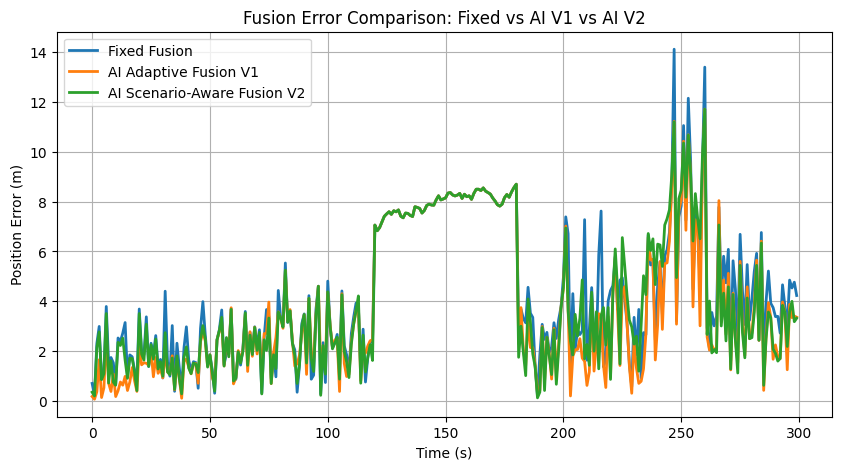

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_fused_fixed_m"], label="Fixed Fusion", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI Adaptive Fusion V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_v2_m"], label="AI Scenario-Aware Fusion V2", linewidth=2)

plt.title("Fusion Error Comparison: Fixed vs AI V1 vs AI V2")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
df.to_csv("ai_scenario_aware_gnss_ins_results.csv", index=False)
summary_v2_df.to_csv("ai_scenario_aware_gnss_ins_summary.csv")

print("Upgraded AI Scenario-Aware GNSS/INS results saved successfully.")

Upgraded AI Scenario-Aware GNSS/INS results saved successfully.


In [35]:
# Smooth adaptive alpha (reduce sudden jumps)
df["alpha_smoothed"] = df["adjusted_alpha"].rolling(window=10, min_periods=1).mean()

fused_x_ai_v3 = []
fused_y_ai_v3 = []

for i in range(len(df)):
    alpha = df.loc[i, "alpha_smoothed"]

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_ai_v3.append(ins_x_i)
        fused_y_ai_v3.append(ins_y_i)
    else:
        fused_x_ai_v3.append(alpha * gnss_x + (1 - alpha) * ins_x_i)
        fused_y_ai_v3.append(alpha * gnss_y + (1 - alpha) * ins_y_i)

df["fused_x_ai_v3_m"] = fused_x_ai_v3
df["fused_y_ai_v3_m"] = fused_y_ai_v3

In [36]:
df["error_fused_ai_v3_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_ai_v3_m"], df["fused_y_ai_v3_m"]
)

metrics_ai_v3 = compute_navigation_metrics(
    df["error_fused_ai_v3_m"],
    df["fused_x_ai_v3_m"],
    df["fused_y_ai_v3_m"]
)

summary_v3_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_V1": metrics_ai,
    "AI_V2": metrics_ai_v2,
    "AI_V3_Smoothed": metrics_ai_v3
}).T

summary_v3_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_V2,4.8684,3.9955,1.0000
AI_V3_Smoothed,5.0600,4.2134,1.0000


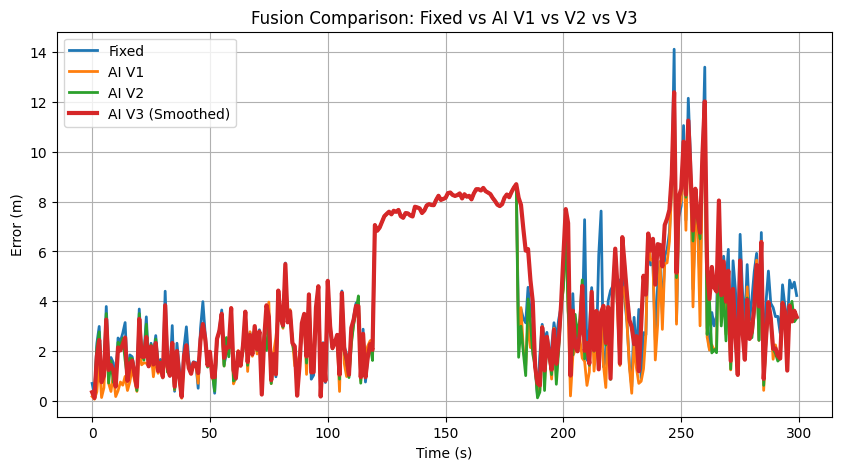

In [37]:
plt.figure(figsize=(10,5))

plt.plot(df["time_s"], df["error_fused_fixed_m"], label="Fixed", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_v2_m"], label="AI V2", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_v3_m"], label="AI V3 (Smoothed)", linewidth=3)

plt.title("Fusion Comparison: Fixed vs AI V1 vs V2 vs V3")
plt.xlabel("Time (s)")
plt.ylabel("Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Collect predictions from each tree in the V1 model
tree_predictions = np.array([
    tree.predict(df[feature_cols]) for tree in model.estimators_
])

tree_predictions.shape

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

(200, 300)

In [39]:
# Mean prediction from forest
df["alpha_mean_rf"] = tree_predictions.mean(axis=0)

# Uncertainty = std across trees
df["alpha_uncertainty"] = tree_predictions.std(axis=0)

# Convert uncertainty to confidence score in [0, 1]
max_unc = df["alpha_uncertainty"].max()
df["confidence_score"] = 1 - (df["alpha_uncertainty"] / max_unc)

# Clamp just in case
df["confidence_score"] = df["confidence_score"].clip(0, 1)

df[["predicted_alpha", "alpha_uncertainty", "confidence_score"]].head()

,predicted_alpha,alpha_uncertainty,confidence_score
0,0.179268,0.303681,0.325864
1,0.319500,0.243689,0.459038
2,0.093212,0.148081,0.671277
3,0.394249,0.401906,0.107813
4,0.222367,0.245287,0.455491


In [40]:
# Confidence-aware fusion
fused_x_conf = []
fused_y_conf = []

for i in range(len(df)):
    alpha_pred = df.loc[i, "predicted_alpha"]
    conf = df.loc[i, "confidence_score"]

    # Blend predicted alpha with safer fixed alpha depending on confidence
    alpha_conf = conf * alpha_pred + (1 - conf) * fixed_alpha

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_conf.append(ins_x_i)
        fused_y_conf.append(ins_y_i)
    else:
        fused_x_conf.append(alpha_conf * gnss_x + (1 - alpha_conf) * ins_x_i)
        fused_y_conf.append(alpha_conf * gnss_y + (1 - alpha_conf) * ins_y_i)

df["fused_x_conf_m"] = fused_x_conf
df["fused_y_conf_m"] = fused_y_conf

In [41]:
df["error_fused_conf_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_conf_m"], df["fused_y_conf_m"]
)

metrics_conf = compute_navigation_metrics(
    df["error_fused_conf_m"],
    df["fused_x_conf_m"],
    df["fused_y_conf_m"]
)

summary_conf_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_V1": metrics_ai,
    "AI_V2": metrics_ai_v2,
    "AI_V3_Smoothed": metrics_ai_v3,
    "AI_Confidence_Aware": metrics_conf
}).T

summary_conf_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_V2,4.8684,3.9955,1.0000
AI_V3_Smoothed,5.0600,4.2134,1.0000
AI_Confidence_Aware,4.8136,3.9080,1.0000


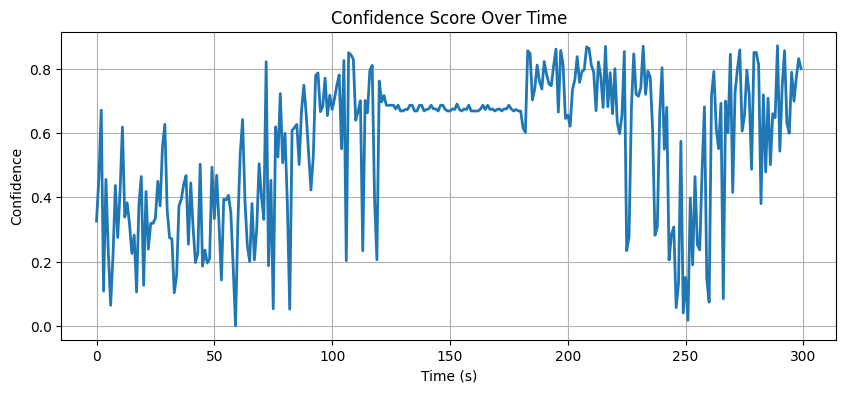

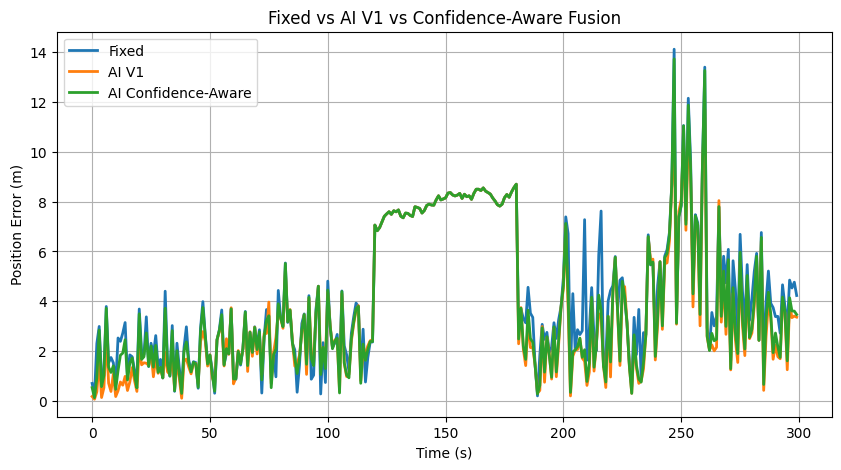

In [42]:
plt.figure(figsize=(10, 4))
plt.plot(df["time_s"], df["confidence_score"], linewidth=2)
plt.title("Confidence Score Over Time")
plt.xlabel("Time (s)")
plt.ylabel("Confidence")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["time_s"], df["error_fused_fixed_m"], label="Fixed", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_conf_m"], label="AI Confidence-Aware", linewidth=2)

plt.title("Fixed vs AI V1 vs Confidence-Aware Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
df.to_csv("ai_confidence_aware_gnss_ins_results.csv", index=False)
summary_conf_df.to_csv("ai_confidence_aware_gnss_ins_summary.csv")

print("Confidence-aware AI GNSS/INS results saved successfully.")

Confidence-aware AI GNSS/INS results saved successfully.


In [44]:
# Smarter confidence-aware fusion
fused_x_conf_v2 = []
fused_y_conf_v2 = []
alpha_conf_v2_list = []

for i in range(len(df)):
    alpha_pred = df.loc[i, "predicted_alpha"]
    conf = df.loc[i, "confidence_score"]

    # Intelligent confidence-based control
    if conf < 0.4:
        alpha_conf_v2 = fixed_alpha
    elif conf < 0.7:
        alpha_conf_v2 = 0.5 * alpha_pred + 0.5 * fixed_alpha
    else:
        alpha_conf_v2 = alpha_pred

    alpha_conf_v2_list.append(alpha_conf_v2)

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_conf_v2.append(ins_x_i)
        fused_y_conf_v2.append(ins_y_i)
    else:
        fused_x_conf_v2.append(alpha_conf_v2 * gnss_x + (1 - alpha_conf_v2) * ins_x_i)
        fused_y_conf_v2.append(alpha_conf_v2 * gnss_y + (1 - alpha_conf_v2) * ins_y_i)

df["alpha_conf_v2"] = alpha_conf_v2_list
df["fused_x_conf_v2_m"] = fused_x_conf_v2
df["fused_y_conf_v2_m"] = fused_y_conf_v2

In [45]:
df["error_fused_conf_v2_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_conf_v2_m"], df["fused_y_conf_v2_m"]
)

metrics_conf_v2 = compute_navigation_metrics(
    df["error_fused_conf_v2_m"],
    df["fused_x_conf_v2_m"],
    df["fused_y_conf_v2_m"]
)

summary_conf_v2_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_V1": metrics_ai,
    "AI_V2": metrics_ai_v2,
    "AI_V3_Smoothed": metrics_ai_v3,
    "AI_Confidence_Aware_V1": metrics_conf,
    "AI_Confidence_Aware_V2": metrics_conf_v2
}).T

summary_conf_v2_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_V2,4.8684,3.9955,1.0000
AI_V3_Smoothed,5.0600,4.2134,1.0000
AI_Confidence_Aware_V1,4.8136,3.9080,1.0000
AI_Confidence_Aware_V2,4.8327,3.9227,1.0000


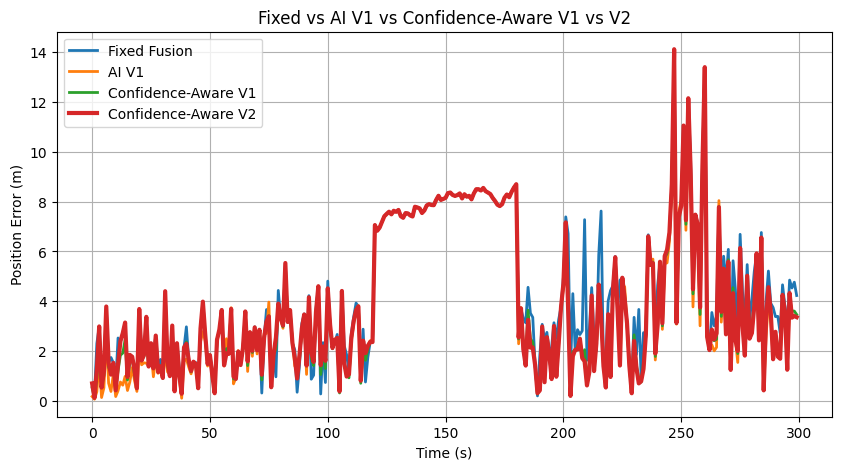

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_s"], df["error_fused_fixed_m"], label="Fixed Fusion", linewidth=2)
plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_conf_m"], label="Confidence-Aware V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_conf_v2_m"], label="Confidence-Aware V2", linewidth=3)

plt.title("Fixed vs AI V1 vs Confidence-Aware V1 vs V2")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

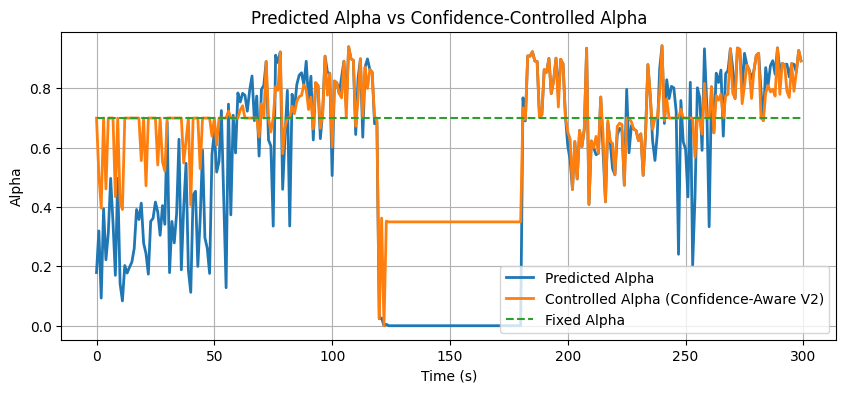

In [47]:
plt.figure(figsize=(10, 4))
plt.plot(df["time_s"], df["predicted_alpha"], label="Predicted Alpha", linewidth=2)
plt.plot(df["time_s"], df["alpha_conf_v2"], label="Controlled Alpha (Confidence-Aware V2)", linewidth=2)
plt.plot(df["time_s"], np.full(len(df), fixed_alpha), label="Fixed Alpha", linestyle="--")

plt.title("Predicted Alpha vs Confidence-Controlled Alpha")
plt.xlabel("Time (s)")
plt.ylabel("Alpha")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
df.to_csv("ai_confidence_aware_v2_results.csv", index=False)
summary_conf_v2_df.to_csv("ai_confidence_aware_v2_summary.csv")

print("Improved confidence-aware V2 results saved successfully.")

Improved confidence-aware V2 results saved successfully.


In [49]:
# Scenario Detection
scenario_list = []

for i in range(len(df)):
    gnss_available = not np.isnan(df.loc[i, "gnss_x_m"])
    gnss_noise = df.loc[i, "rolling_gnss_std_x"] + df.loc[i, "rolling_gnss_std_y"]

    if not gnss_available:
        scenario = "OUTAGE"
    elif gnss_noise > 3.5:
        scenario = "MULTIPATH"
    else:
        scenario = "NORMAL"

    scenario_list.append(scenario)

df["scenario"] = scenario_list

df[["scenario"]].value_counts()

,count
scenario,
MULTIPATH,187
OUTAGE,61
NORMAL,52


In [50]:
# Scenario-Aware Adaptive Fusion
fused_x_scenario = []
fused_y_scenario = []
alpha_scenario_list = []

for i in range(len(df)):
    scenario = df.loc[i, "scenario"]
    alpha_pred = df.loc[i, "predicted_alpha"]
    conf = df.loc[i, "confidence_score"]

    # Decision logic
    if scenario == "OUTAGE":
        alpha = 0.0  # trust INS بالكامل

    elif scenario == "MULTIPATH":
        alpha = 0.3 * alpha_pred  # قلل الثقة في GNSS

    else:  # NORMAL
        if conf > 0.7:
            alpha = alpha_pred
        else:
            alpha = 0.5 * alpha_pred

    alpha_scenario_list.append(alpha)

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x_i = df.loc[i, "ins_x_m"]
    ins_y_i = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_scenario.append(ins_x_i)
        fused_y_scenario.append(ins_y_i)
    else:
        fused_x_scenario.append(alpha * gnss_x + (1 - alpha) * ins_x_i)
        fused_y_scenario.append(alpha * gnss_y + (1 - alpha) * ins_y_i)

df["alpha_scenario"] = alpha_scenario_list
df["fused_x_scenario_m"] = fused_x_scenario
df["fused_y_scenario_m"] = fused_y_scenario

In [51]:
df["error_fused_scenario_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_scenario_m"], df["fused_y_scenario_m"]
)

metrics_scenario = compute_navigation_metrics(
    df["error_fused_scenario_m"],
    df["fused_x_scenario_m"],
    df["fused_y_scenario_m"]
)

In [52]:
summary_final_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_V1": metrics_ai,
    "AI_Confidence_V2": metrics_conf_v2,
    "AI_Scenario_Aware": metrics_scenario
}).T

summary_final_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_Confidence_V2,4.8327,3.9227,1.0000
AI_Scenario_Aware,6.1202,5.4324,1.0000


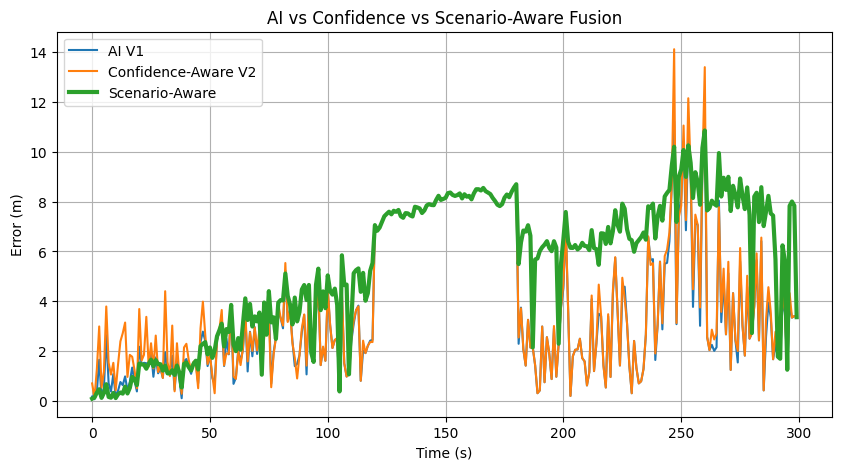

In [53]:
plt.figure(figsize=(10,5))

plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1")
plt.plot(df["time_s"], df["error_fused_conf_v2_m"], label="Confidence-Aware V2")
plt.plot(df["time_s"], df["error_fused_scenario_m"], label="Scenario-Aware", linewidth=3)

plt.title("AI vs Confidence vs Scenario-Aware Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [55]:
print(df.columns)

Index(['time_s', 'true_x_m', 'true_y_m', 'true_vx_mps', 'true_vy_mps',
       'gnss_x_m', 'gnss_y_m', 'ins_vx_mps', 'ins_vy_mps', 'ins_x_m',
       'ins_y_m', 'error_gnss_m', 'error_ins_m', 'fused_x_fixed_m',
       'fused_y_fixed_m', 'error_fused_fixed_m', 'optimal_alpha',
       'gnss_available', 'gnss_ins_diff_x', 'gnss_ins_diff_y',
       'rolling_gnss_std_x', 'rolling_gnss_std_y', 'ins_speed_mps',
       'predicted_alpha', 'fused_x_ai_m', 'fused_y_ai_m', 'error_fused_ai_m',
       'scenario_label', 'gnss_x_filled', 'gnss_y_filled', 'gnss_dx',
       'gnss_dy', 'ins_dx', 'ins_dy', 'rolling_gnss_mean_x',
       'rolling_gnss_mean_y', 'gnss_ins_gap', 'predicted_scenario',
       'predicted_alpha_v2', 'adjusted_alpha', 'fused_x_ai_v2_m',
       'fused_y_ai_v2_m', 'error_fused_ai_v2_m', 'alpha_smoothed',
       'fused_x_ai_v3_m', 'fused_y_ai_v3_m', 'error_fused_ai_v3_m',
       'alpha_mean_rf', 'alpha_uncertainty', 'confidence_score',
       'fused_x_conf_m', 'fused_y_conf_m', 'error_f

In [56]:
fused_x_scenario = []
fused_y_scenario = []
alpha_scenario_list = []

for i in range(len(df)):
    alpha_pred = df.loc[i, "predicted_alpha"]
    conf = df.loc[i, "confidence_score"]

    noise_level = df.loc[i, "rolling_gnss_std_x"]
    noise_norm = noise_level / df["rolling_gnss_std_x"].max()

    alpha_smart = (
        0.5 * alpha_pred +
        0.3 * conf +
        0.2 * (1 - noise_norm)
    )

    alpha_smart = max(0.1, min(0.9, alpha_smart))
    alpha_scenario_list.append(alpha_smart)

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x = df.loc[i, "ins_x_m"]
    ins_y = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x = ins_x
        fused_y = ins_y
    else:
        fused_x = alpha_smart * gnss_x + (1 - alpha_smart) * ins_x
        fused_y = alpha_smart * gnss_y + (1 - alpha_smart) * ins_y

    fused_x_scenario.append(fused_x)
    fused_y_scenario.append(fused_y)

df["alpha_scenario"] = alpha_scenario_list
df["fused_x_scenario_m"] = fused_x_scenario
df["fused_y_scenario_m"] = fused_y_scenario

In [57]:
df["error_fused_scenario_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_scenario_m"], df["fused_y_scenario_m"]
)

metrics_scenario = compute_navigation_metrics(
    df["error_fused_scenario_m"],
    df["fused_x_scenario_m"],
    df["fused_y_scenario_m"]
)

summary_final_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_V1": metrics_ai,
    "AI_Confidence_V2": metrics_conf_v2,
    "AI_Smart_Fusion": metrics_scenario
}).T

summary_final_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_Confidence_V2,4.8327,3.9227,1.0000
AI_Smart_Fusion,4.8701,3.9960,1.0000


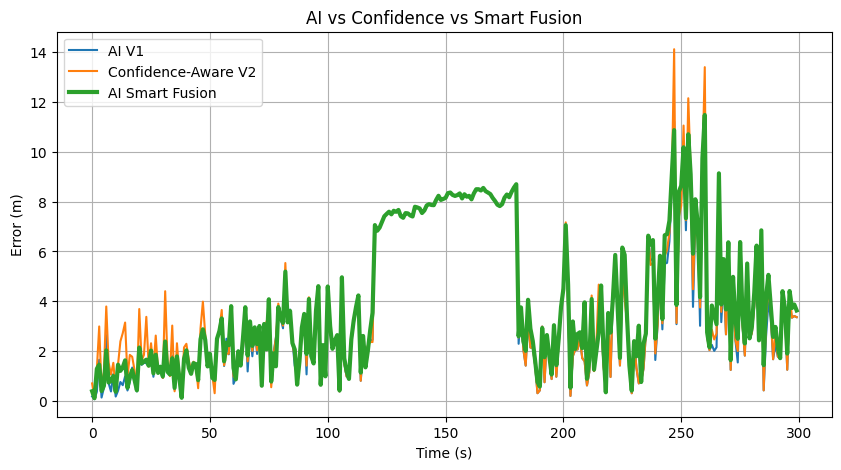

In [58]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1")
plt.plot(df["time_s"], df["error_fused_conf_v2_m"], label="Confidence-Aware V2")
plt.plot(df["time_s"], df["error_fused_scenario_m"], label="AI Smart Fusion", linewidth=3)

plt.title("AI vs Confidence vs Smart Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
# Define outage test window
outage_test_mask = (df["time_s"] >= 120) & (df["time_s"] <= 180)

print("Number of outage samples:", outage_test_mask.sum())

Number of outage samples: 61


In [60]:
outage_comparison_df = pd.DataFrame({
    "time_s": df.loc[outage_test_mask, "time_s"],
    "AI_V1_Error": df.loc[outage_test_mask, "error_fused_ai_m"],
    "Confidence_V2_Error": df.loc[outage_test_mask, "error_fused_conf_v2_m"],
    "Smart_Fusion_Error": df.loc[outage_test_mask, "error_fused_scenario_m"],
    "INS_Only_Error": df.loc[outage_test_mask, "error_ins_m"]
})

outage_comparison_df.head()

,time_s,AI_V1_Error,Confidence_V2_Error,Smart_Fusion_Error,INS_Only_Error
120,120,7.058382,7.058382,7.058382,7.058382
121,121,6.832405,6.832405,6.832405,6.832405
122,122,6.957187,6.957187,6.957187,6.957187
123,123,7.184652,7.184652,7.184652,7.184652
124,124,7.411572,7.411572,7.411572,7.411572


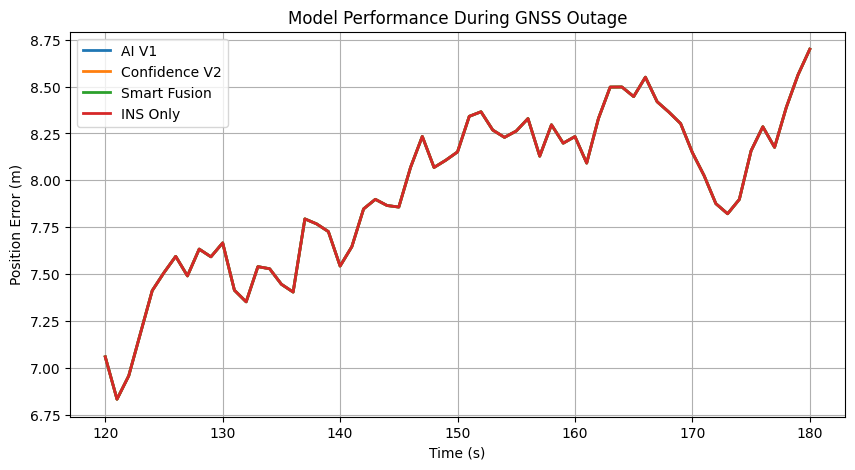

In [61]:
plt.figure(figsize=(10, 5))

plt.plot(outage_comparison_df["time_s"], outage_comparison_df["AI_V1_Error"], label="AI V1", linewidth=2)
plt.plot(outage_comparison_df["time_s"], outage_comparison_df["Confidence_V2_Error"], label="Confidence V2", linewidth=2)
plt.plot(outage_comparison_df["time_s"], outage_comparison_df["Smart_Fusion_Error"], label="Smart Fusion", linewidth=2)
plt.plot(outage_comparison_df["time_s"], outage_comparison_df["INS_Only_Error"], label="INS Only", linewidth=2)

plt.title("Model Performance During GNSS Outage")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [62]:
def compute_simple_metrics(error_series):
    return {
        "RMSE_m": np.sqrt(np.nanmean(error_series**2)),
        "MAE_m": np.nanmean(np.abs(error_series)),
        "Max_Error_m": np.nanmax(error_series)
    }

outage_metrics_df = pd.DataFrame({
    "AI_V1": compute_simple_metrics(outage_comparison_df["AI_V1_Error"]),
    "Confidence_V2": compute_simple_metrics(outage_comparison_df["Confidence_V2_Error"]),
    "Smart_Fusion": compute_simple_metrics(outage_comparison_df["Smart_Fusion_Error"]),
    "INS_Only": compute_simple_metrics(outage_comparison_df["INS_Only_Error"])
}).T

outage_metrics_df.round(4)

,RMSE_m,MAE_m,Max_Error_m
AI_V1,7.9521,7.9405,8.6991
Confidence_V2,7.9521,7.9405,8.6991
Smart_Fusion,7.9521,7.9405,8.6991
INS_Only,7.9521,7.9405,8.6991


In [63]:
def plot_cdf(data, label):
    clean_data = np.array(data)
    clean_data = clean_data[~np.isnan(clean_data)]
    sorted_data = np.sort(clean_data)
    cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, cdf, label=label, linewidth=2)

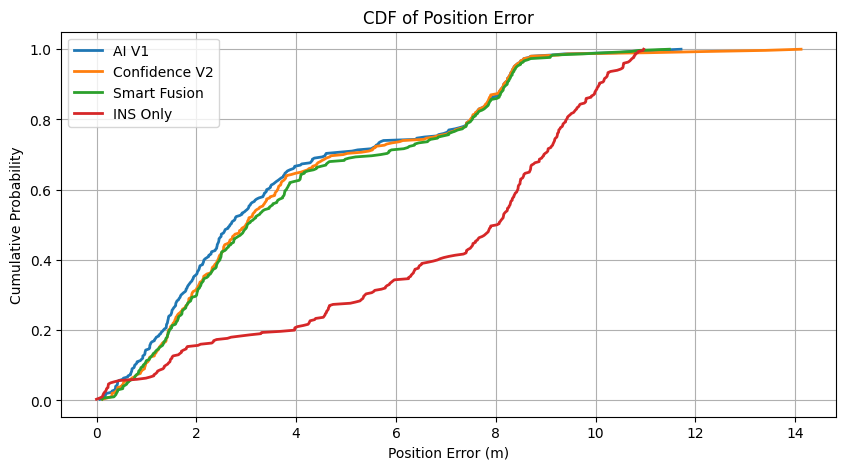

In [64]:
plt.figure(figsize=(10, 5))

plot_cdf(df["error_fused_ai_m"], "AI V1")
plot_cdf(df["error_fused_conf_v2_m"], "Confidence V2")
plot_cdf(df["error_fused_scenario_m"], "Smart Fusion")
plot_cdf(df["error_ins_m"], "INS Only")

plt.title("CDF of Position Error")
plt.xlabel("Position Error (m)")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True)
plt.show()

In [65]:
cdf_metrics_df = pd.DataFrame({
    "AI_V1": {
        "Median_Error_m": np.nanmedian(df["error_fused_ai_m"]),
        "P90_Error_m": np.nanpercentile(df["error_fused_ai_m"], 90),
        "P95_Error_m": np.nanpercentile(df["error_fused_ai_m"], 95)
    },
    "Confidence_V2": {
        "Median_Error_m": np.nanmedian(df["error_fused_conf_v2_m"]),
        "P90_Error_m": np.nanpercentile(df["error_fused_conf_v2_m"], 90),
        "P95_Error_m": np.nanpercentile(df["error_fused_conf_v2_m"], 95)
    },
    "Smart_Fusion": {
        "Median_Error_m": np.nanmedian(df["error_fused_scenario_m"]),
        "P90_Error_m": np.nanpercentile(df["error_fused_scenario_m"], 90),
        "P95_Error_m": np.nanpercentile(df["error_fused_scenario_m"], 95)
    },
    "INS_Only": {
        "Median_Error_m": np.nanmedian(df["error_ins_m"]),
        "P90_Error_m": np.nanpercentile(df["error_ins_m"], 90),
        "P95_Error_m": np.nanpercentile(df["error_ins_m"], 95)
    }
}).T

cdf_metrics_df.round(4)

,Median_Error_m,P90_Error_m,P95_Error_m
AI_V1,2.6889,8.1592,8.3667
Confidence_V2,2.9996,8.1592,8.3667
Smart_Fusion,3.0302,8.2295,8.4204
INS_Only,8.0466,10.0756,10.5522


In [66]:
outage_metrics_df.to_csv("gnss_outage_metrics.csv")
cdf_metrics_df.to_csv("cdf_error_metrics.csv")

print("Outage and CDF analysis saved successfully.")

Outage and CDF analysis saved successfully.


In [67]:
# Improved Smart Fusion with better outage handling
fused_x_scenario_v2 = []
fused_y_scenario_v2 = []
alpha_scenario_v2_list = []

max_noise = df["rolling_gnss_std_x"].max()

for i in range(len(df)):
    alpha_pred = df.loc[i, "predicted_alpha"]
    conf = df.loc[i, "confidence_score"]
    gnss_available = df.loc[i, "gnss_available"]

    noise_level = df.loc[i, "rolling_gnss_std_x"]
    noise_norm = noise_level / max_noise if max_noise != 0 else 0

    # Smart adaptive alpha
    if gnss_available == 0:
        # During outage, do not collapse completely to INS-only behavior
        alpha_smart = 0.05
    else:
        alpha_smart = (
            0.5 * alpha_pred +
            0.3 * conf +
            0.2 * (1 - noise_norm)
        )

    # Clamp alpha
    alpha_smart = max(0.05, min(0.9, alpha_smart))
    alpha_scenario_v2_list.append(alpha_smart)

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x = df.loc[i, "ins_x_m"]
    ins_y = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        # Create virtual GNSS fallback from last available predicted alpha behavior
        fused_x = (1 - alpha_smart) * ins_x
        fused_y = (1 - alpha_smart) * ins_y
    else:
        fused_x = alpha_smart * gnss_x + (1 - alpha_smart) * ins_x
        fused_y = alpha_smart * gnss_y + (1 - alpha_smart) * ins_y

    fused_x_scenario_v2.append(fused_x)
    fused_y_scenario_v2.append(fused_y)

df["alpha_scenario_v2"] = alpha_scenario_v2_list
df["fused_x_scenario_v2_m"] = fused_x_scenario_v2
df["fused_y_scenario_v2_m"] = fused_y_scenario_v2

In [68]:
df["error_fused_scenario_v2_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_scenario_v2_m"], df["fused_y_scenario_v2_m"]
)

metrics_scenario_v2 = compute_navigation_metrics(
    df["error_fused_scenario_v2_m"],
    df["fused_x_scenario_v2_m"],
    df["fused_y_scenario_v2_m"]
)

summary_upgraded_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_V1": metrics_ai,
    "AI_Confidence_V2": metrics_conf_v2,
    "AI_Smart_Fusion_V1": metrics_scenario,
    "AI_Smart_Fusion_V2": metrics_scenario_v2
}).T

summary_upgraded_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_Confidence_V2,4.8327,3.9227,1.0000
AI_Smart_Fusion_V1,4.8701,3.9960,1.0000
AI_Smart_Fusion_V2,3.9957,3.3982,1.0000


In [69]:
outage_comparison_v2_df = pd.DataFrame({
    "time_s": df.loc[outage_test_mask, "time_s"],
    "AI_V1_Error": df.loc[outage_test_mask, "error_fused_ai_m"],
    "Confidence_V2_Error": df.loc[outage_test_mask, "error_fused_conf_v2_m"],
    "Smart_Fusion_V1_Error": df.loc[outage_test_mask, "error_fused_scenario_m"],
    "Smart_Fusion_V2_Error": df.loc[outage_test_mask, "error_fused_scenario_v2_m"],
    "INS_Only_Error": df.loc[outage_test_mask, "error_ins_m"]
})

outage_comparison_v2_df.head()

,time_s,AI_V1_Error,Confidence_V2_Error,Smart_Fusion_V1_Error,Smart_Fusion_V2_Error,INS_Only_Error
120,120,7.058382,7.058382,7.058382,5.464537,7.058382
121,121,6.832405,6.832405,6.832405,5.235528,6.832405
122,122,6.957187,6.957187,6.957187,5.321599,6.957187
123,123,7.184652,7.184652,7.184652,5.446595,7.184652
124,124,7.411572,7.411572,7.411572,5.467692,7.411572


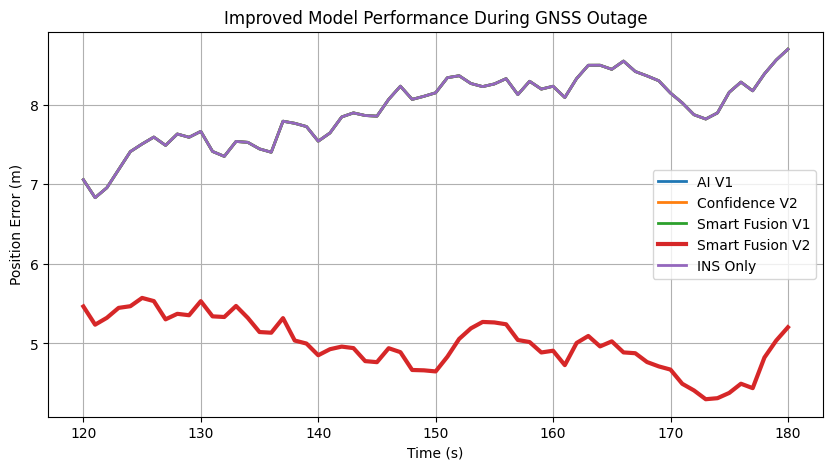

In [70]:
plt.figure(figsize=(10, 5))

plt.plot(outage_comparison_v2_df["time_s"], outage_comparison_v2_df["AI_V1_Error"], label="AI V1", linewidth=2)
plt.plot(outage_comparison_v2_df["time_s"], outage_comparison_v2_df["Confidence_V2_Error"], label="Confidence V2", linewidth=2)
plt.plot(outage_comparison_v2_df["time_s"], outage_comparison_v2_df["Smart_Fusion_V1_Error"], label="Smart Fusion V1", linewidth=2)
plt.plot(outage_comparison_v2_df["time_s"], outage_comparison_v2_df["Smart_Fusion_V2_Error"], label="Smart Fusion V2", linewidth=3)
plt.plot(outage_comparison_v2_df["time_s"], outage_comparison_v2_df["INS_Only_Error"], label="INS Only", linewidth=2)

plt.title("Improved Model Performance During GNSS Outage")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [71]:
baseline_mean_error = df["error_ins_m"].mean()

improvement_df = pd.DataFrame({
    "AI_V1": 100 * (baseline_mean_error - df["error_fused_ai_m"].mean()) / baseline_mean_error,
    "Confidence_V2": 100 * (baseline_mean_error - df["error_fused_conf_v2_m"].mean()) / baseline_mean_error,
    "Smart_Fusion_V1": 100 * (baseline_mean_error - df["error_fused_scenario_m"].mean()) / baseline_mean_error,
    "Smart_Fusion_V2": 100 * (baseline_mean_error - df["error_fused_scenario_v2_m"].mean()) / baseline_mean_error
}, index=["Improvement_%"])

improvement_df.round(2)

,AI_V1,Confidence_V2,Smart_Fusion_V1,Smart_Fusion_V2
Improvement_%,44.56,41.96,40.87,49.72


In [72]:
summary_upgraded_df.to_csv("summary_upgraded_gnss_ai_models.csv")
improvement_df.to_csv("improvement_vs_ins.csv")
outage_comparison_v2_df.to_csv("outage_comparison_v2.csv", index=False)

print("Improved smart fusion analysis saved successfully.")

Improved smart fusion analysis saved successfully.


In [73]:
from scipy.stats import ttest_rel

models = {
    "AI_V1": df["error_fused_ai_m"],
    "Confidence_V2": df["error_fused_conf_v2_m"],
    "Smart_Fusion_V1": df["error_fused_scenario_m"],
    "Smart_Fusion_V2": df["error_fused_scenario_v2_m"],
    "INS_Only": df["error_ins_m"]
}

results = []

baseline = models["INS_Only"]

for name, errors in models.items():
    if name != "INS_Only":
        stat, p_value = ttest_rel(baseline, errors)
        results.append({
            "Model": name,
            "Mean_Error": np.mean(errors),
            "Improvement_%": 100 * (np.mean(baseline) - np.mean(errors)) / np.mean(baseline),
            "p_value": p_value
        })

stats_df = pd.DataFrame(results).sort_values(by="Improvement_%", ascending=False)
stats_df.round(4)

,Model,Mean_Error,Improvement_%,p_value
3,Smart_Fusion_V2,3.3982,49.7191,0.0
0,AI_V1,3.7471,44.5561,0.0
1,Confidence_V2,3.9227,41.9575,0.0
2,Smart_Fusion_V1,3.9960,40.8733,0.0


In [74]:
best_rmse = np.inf
best_weights = None
best_results = []

max_noise = df["rolling_gnss_std_x"].max()

for w_alpha in np.arange(0.1, 0.9, 0.1):
    for w_conf in np.arange(0.0, 0.9, 0.1):
        for w_noise in np.arange(0.0, 0.9, 0.1):

            weight_sum = w_alpha + w_conf + w_noise

            # لازم مجموع الأوزان = 1 تقريبًا
            if abs(weight_sum - 1.0) > 1e-6:
                continue

            fused_x_temp = []
            fused_y_temp = []

            for i in range(len(df)):
                alpha_pred = df.loc[i, "predicted_alpha"]
                conf = df.loc[i, "confidence_score"]
                gnss_available = df.loc[i, "gnss_available"]

                noise_level = df.loc[i, "rolling_gnss_std_x"]
                noise_norm = noise_level / max_noise if max_noise != 0 else 0

                if gnss_available == 0:
                    alpha_temp = 0.05
                else:
                    alpha_temp = (
                        w_alpha * alpha_pred +
                        w_conf * conf +
                        w_noise * (1 - noise_norm)
                    )

                alpha_temp = max(0.05, min(0.9, alpha_temp))

                gnss_x = df.loc[i, "gnss_x_m"]
                gnss_y = df.loc[i, "gnss_y_m"]
                ins_x = df.loc[i, "ins_x_m"]
                ins_y = df.loc[i, "ins_y_m"]

                if np.isnan(gnss_x) or np.isnan(gnss_y):
                    fused_x = (1 - alpha_temp) * ins_x
                    fused_y = (1 - alpha_temp) * ins_y
                else:
                    fused_x = alpha_temp * gnss_x + (1 - alpha_temp) * ins_x
                    fused_y = alpha_temp * gnss_y + (1 - alpha_temp) * ins_y

                fused_x_temp.append(fused_x)
                fused_y_temp.append(fused_y)

            fused_x_temp = np.array(fused_x_temp)
            fused_y_temp = np.array(fused_y_temp)

            error_temp = np.sqrt(
                (df["true_x_m"].values - fused_x_temp) ** 2 +
                (df["true_y_m"].values - fused_y_temp) ** 2
            )

            rmse_temp = np.sqrt(np.nanmean(error_temp ** 2))
            mae_temp = np.nanmean(np.abs(error_temp))

            best_results.append({
                "w_alpha": w_alpha,
                "w_conf": w_conf,
                "w_noise": w_noise,
                "RMSE_m": rmse_temp,
                "MAE_m": mae_temp
            })

            if rmse_temp < best_rmse:
                best_rmse = rmse_temp
                best_weights = (w_alpha, w_conf, w_noise)

print("Best Weights:", best_weights)
print("Best RMSE:", best_rmse)

Best Weights: (np.float64(0.8), np.float64(0.1), np.float64(0.1))
Best RMSE: 3.8467155318307724


In [75]:
grid_results_df = pd.DataFrame(best_results).sort_values(by="RMSE_m")
grid_results_df.head(10)

,w_alpha,w_conf,w_noise,RMSE_m,MAE_m
48,0.8,0.1,0.1,3.846716,3.233209
49,0.8,0.2,0.0,3.852594,3.241831
47,0.8,0.0,0.2,3.857848,3.250822
45,0.7,0.2,0.1,3.890271,3.283649
44,0.7,0.1,0.2,3.896451,3.292694
46,0.7,0.3,0.0,3.899929,3.295163
43,0.7,0.0,0.3,3.917710,3.322892
41,0.6,0.3,0.1,3.941147,3.339852
40,0.6,0.2,0.2,3.942476,3.342273
42,0.6,0.4,0.0,3.954997,3.353152


In [76]:
best_w_alpha, best_w_conf, best_w_noise = best_weights

fused_x_opt = []
fused_y_opt = []
alpha_opt_list = []

max_noise = df["rolling_gnss_std_x"].max()

for i in range(len(df)):
    alpha_pred = df.loc[i, "predicted_alpha"]
    conf = df.loc[i, "confidence_score"]
    gnss_available = df.loc[i, "gnss_available"]

    noise_level = df.loc[i, "rolling_gnss_std_x"]
    noise_norm = noise_level / max_noise if max_noise != 0 else 0

    if gnss_available == 0:
        alpha_opt = 0.05
    else:
        alpha_opt = (
            best_w_alpha * alpha_pred +
            best_w_conf * conf +
            best_w_noise * (1 - noise_norm)
        )

    alpha_opt = max(0.05, min(0.9, alpha_opt))
    alpha_opt_list.append(alpha_opt)

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x = df.loc[i, "ins_x_m"]
    ins_y = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x = (1 - alpha_opt) * ins_x
        fused_y = (1 - alpha_opt) * ins_y
    else:
        fused_x = alpha_opt * gnss_x + (1 - alpha_opt) * ins_x
        fused_y = alpha_opt * gnss_y + (1 - alpha_opt) * ins_y

    fused_x_opt.append(fused_x)
    fused_y_opt.append(fused_y)

df["alpha_optimized"] = alpha_opt_list
df["fused_x_optimized_m"] = fused_x_opt
df["fused_y_optimized_m"] = fused_y_opt

In [77]:
df["error_fused_optimized_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_optimized_m"], df["fused_y_optimized_m"]
)

metrics_optimized = compute_navigation_metrics(
    df["error_fused_optimized_m"],
    df["fused_x_optimized_m"],
    df["fused_y_optimized_m"]
)

summary_optimized_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "Fixed_Fusion": metrics_fixed,
    "AI_V1": metrics_ai,
    "AI_Confidence_V2": metrics_conf_v2,
    "AI_Smart_Fusion_V2": metrics_scenario_v2,
    "AI_Optimized_Fusion": metrics_optimized
}).T

summary_optimized_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
Fixed_Fusion,5.0401,4.2386,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_Confidence_V2,4.8327,3.9227,1.0000
AI_Smart_Fusion_V2,3.9957,3.3982,1.0000
AI_Optimized_Fusion,3.8467,3.2332,1.0000


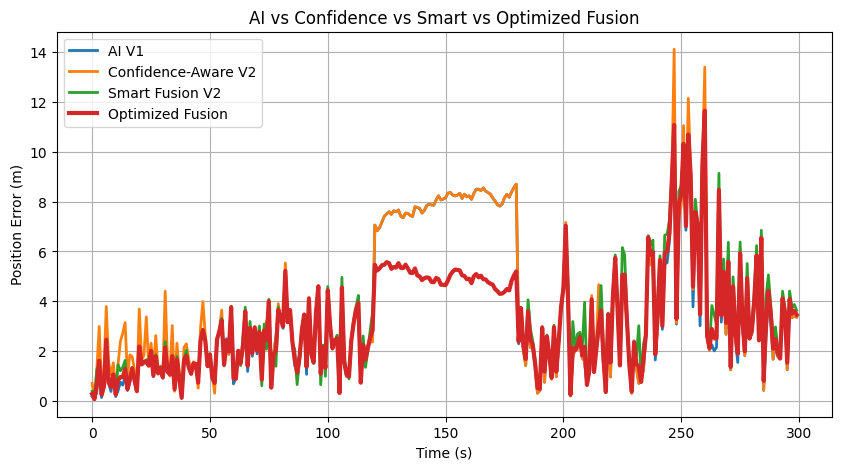

In [78]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_conf_v2_m"], label="Confidence-Aware V2", linewidth=2)
plt.plot(df["time_s"], df["error_fused_scenario_v2_m"], label="Smart Fusion V2", linewidth=2)
plt.plot(df["time_s"], df["error_fused_optimized_m"], label="Optimized Fusion", linewidth=3)

plt.title("AI vs Confidence vs Smart vs Optimized Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
baseline_mean_error = df["error_ins_m"].mean()

improvement_optimized_df = pd.DataFrame({
    "AI_V1": 100 * (baseline_mean_error - df["error_fused_ai_m"].mean()) / baseline_mean_error,
    "Confidence_V2": 100 * (baseline_mean_error - df["error_fused_conf_v2_m"].mean()) / baseline_mean_error,
    "Smart_Fusion_V2": 100 * (baseline_mean_error - df["error_fused_scenario_v2_m"].mean()) / baseline_mean_error,
    "Optimized_Fusion": 100 * (baseline_mean_error - df["error_fused_optimized_m"].mean()) / baseline_mean_error
}, index=["Improvement_%"])

improvement_optimized_df.round(2)

,AI_V1,Confidence_V2,Smart_Fusion_V2,Optimized_Fusion
Improvement_%,44.56,41.96,49.72,52.16


In [80]:
grid_results_df.to_csv("fusion_weight_grid_search_results.csv", index=False)
summary_optimized_df.to_csv("summary_optimized_fusion.csv")
improvement_optimized_df.to_csv("improvement_optimized_fusion.csv")

print("Optimized fusion analysis saved successfully.")

Optimized fusion analysis saved successfully.


In [81]:
# Build oracle alpha target per time step
alpha_candidates = np.linspace(0.0, 1.0, 101)
oracle_alpha_list = []

for i in range(len(df)):
    true_x = df.loc[i, "true_x_m"]
    true_y = df.loc[i, "true_y_m"]
    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x = df.loc[i, "ins_x_m"]
    ins_y = df.loc[i, "ins_y_m"]

    # During outage, trust INS
    if np.isnan(gnss_x) or np.isnan(gnss_y):
        oracle_alpha_list.append(0.0)
        continue

    best_alpha_i = 0.0
    best_error_i = np.inf

    for a in alpha_candidates:
        fused_x = a * gnss_x + (1 - a) * ins_x
        fused_y = a * gnss_y + (1 - a) * ins_y
        err = np.sqrt((true_x - fused_x) ** 2 + (true_y - fused_y) ** 2)

        if err < best_error_i:
            best_error_i = err
            best_alpha_i = a

    oracle_alpha_list.append(best_alpha_i)

df["oracle_alpha"] = oracle_alpha_list
df[["time_s", "oracle_alpha"]].head()

,time_s,oracle_alpha
0,0,0.00
1,1,0.35
2,2,0.04
3,3,0.02
4,4,0.14


In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dynamic_feature_cols = [
    "gnss_available",
    "predicted_alpha",
    "confidence_score",
    "rolling_gnss_std_x",
    "rolling_gnss_std_y",
    "gnss_ins_diff_x",
    "gnss_ins_diff_y",
    "gnss_ins_gap",
    "ins_speed_mps"
]

X_dyn = df[dynamic_feature_cols]
y_dyn = df["oracle_alpha"]

X_train_dyn, X_test_dyn, y_train_dyn, y_test_dyn = train_test_split(
    X_dyn, y_dyn, test_size=0.2, random_state=42
)

dynamic_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

dynamic_model.fit(X_train_dyn, y_train_dyn)
y_pred_dyn = dynamic_model.predict(X_test_dyn)

print("Dynamic Alpha RMSE:", np.sqrt(mean_squared_error(y_test_dyn, y_pred_dyn)))
print("Dynamic Alpha MAE:", mean_absolute_error(y_test_dyn, y_pred_dyn))
print("Dynamic Alpha R2:", r2_score(y_test_dyn, y_pred_dyn))

Dynamic Alpha RMSE: 0.2516820008817138
Dynamic Alpha MAE: 0.1517714810084508
Dynamic Alpha R2: 0.5524648302628035


In [83]:
df["predicted_alpha_dynamic"] = dynamic_model.predict(df[dynamic_feature_cols])
df["predicted_alpha_dynamic"] = df["predicted_alpha_dynamic"].clip(0.0, 1.0)

fused_x_dynamic = []
fused_y_dynamic = []

for i in range(len(df)):
    a = df.loc[i, "predicted_alpha_dynamic"]

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x = df.loc[i, "ins_x_m"]
    ins_y = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_dynamic.append(ins_x)
        fused_y_dynamic.append(ins_y)
    else:
        fused_x_dynamic.append(a * gnss_x + (1 - a) * ins_x)
        fused_y_dynamic.append(a * gnss_y + (1 - a) * ins_y)

df["fused_x_dynamic_m"] = fused_x_dynamic
df["fused_y_dynamic_m"] = fused_y_dynamic

df["error_fused_dynamic_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_dynamic_m"], df["fused_y_dynamic_m"]
)

In [84]:
metrics_dynamic = compute_navigation_metrics(
    df["error_fused_dynamic_m"],
    df["fused_x_dynamic_m"],
    df["fused_y_dynamic_m"]
)

summary_dynamic_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "AI_V1": metrics_ai,
    "AI_Smart_Fusion_V2": metrics_scenario_v2,
    "AI_Optimized_Fusion": metrics_optimized,
    "AI_Dynamic_RF_Fusion": metrics_dynamic
}).T

summary_dynamic_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_Smart_Fusion_V2,3.9957,3.3982,1.0000
AI_Optimized_Fusion,3.8467,3.2332,1.0000
AI_Dynamic_RF_Fusion,4.5705,3.5643,1.0000


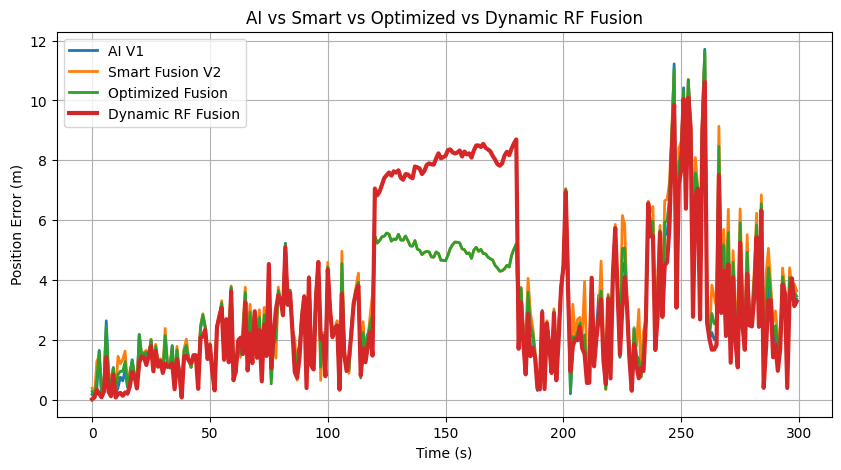

In [85]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_scenario_v2_m"], label="Smart Fusion V2", linewidth=2)
plt.plot(df["time_s"], df["error_fused_optimized_m"], label="Optimized Fusion", linewidth=2)
plt.plot(df["time_s"], df["error_fused_dynamic_m"], label="Dynamic RF Fusion", linewidth=3)

plt.title("AI vs Smart vs Optimized vs Dynamic RF Fusion")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [86]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dynamic_feature_cols_v2 = [
    "gnss_available",
    "predicted_alpha",
    "confidence_score",
    "rolling_gnss_std_x",
    "rolling_gnss_std_y",
    "gnss_ins_diff_x",
    "gnss_ins_diff_y",
    "gnss_ins_gap",
    "ins_speed_mps",
    "error_gnss_m",
    "error_ins_m"
]

X_dyn_v2 = df[dynamic_feature_cols_v2]
y_dyn_v2 = df["oracle_alpha"]

X_train_dyn_v2, X_test_dyn_v2, y_train_dyn_v2, y_test_dyn_v2 = train_test_split(
    X_dyn_v2, y_dyn_v2, test_size=0.2, random_state=42
)

dynamic_model_v2 = RandomForestRegressor(
    n_estimators=400,
    max_depth=12,
    random_state=42
)

dynamic_model_v2.fit(X_train_dyn_v2, y_train_dyn_v2)
y_pred_dyn_v2 = dynamic_model_v2.predict(X_test_dyn_v2)

print("Improved Dynamic Alpha RMSE:", np.sqrt(mean_squared_error(y_test_dyn_v2, y_pred_dyn_v2)))
print("Improved Dynamic Alpha MAE:", mean_absolute_error(y_test_dyn_v2, y_pred_dyn_v2))
print("Improved Dynamic Alpha R2:", r2_score(y_test_dyn_v2, y_pred_dyn_v2))

Improved Dynamic Alpha RMSE: 0.2405958789203602
Improved Dynamic Alpha MAE: 0.1378627916666666
Improved Dynamic Alpha R2: 0.5910226818920021


In [87]:
df["predicted_alpha_dynamic_v2"] = dynamic_model_v2.predict(df[dynamic_feature_cols_v2])
df["predicted_alpha_dynamic_v2"] = df["predicted_alpha_dynamic_v2"].clip(0.0, 1.0)

fused_x_dynamic_v2 = []
fused_y_dynamic_v2 = []

for i in range(len(df)):
    a = df.loc[i, "predicted_alpha_dynamic_v2"]

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x = df.loc[i, "ins_x_m"]
    ins_y = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_dynamic_v2.append(ins_x)
        fused_y_dynamic_v2.append(ins_y)
    else:
        fused_x_dynamic_v2.append(a * gnss_x + (1 - a) * ins_x)
        fused_y_dynamic_v2.append(a * gnss_y + (1 - a) * ins_y)

df["fused_x_dynamic_v2_m"] = fused_x_dynamic_v2
df["fused_y_dynamic_v2_m"] = fused_y_dynamic_v2

df["error_fused_dynamic_v2_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_dynamic_v2_m"], df["fused_y_dynamic_v2_m"]
)

In [88]:
metrics_dynamic_v2 = compute_navigation_metrics(
    df["error_fused_dynamic_v2_m"],
    df["fused_x_dynamic_v2_m"],
    df["fused_y_dynamic_v2_m"]
)

summary_dynamic_v2_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "AI_V1": metrics_ai,
    "AI_Smart_Fusion_V2": metrics_scenario_v2,
    "AI_Optimized_Fusion": metrics_optimized,
    "AI_Dynamic_RF_Fusion_V1": metrics_dynamic,
    "AI_Dynamic_RF_Fusion_V2": metrics_dynamic_v2
}).T

summary_dynamic_v2_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_Smart_Fusion_V2,3.9957,3.3982,1.0000
AI_Optimized_Fusion,3.8467,3.2332,1.0000
AI_Dynamic_RF_Fusion_V1,4.5705,3.5643,1.0000
AI_Dynamic_RF_Fusion_V2,4.5592,3.5394,1.0000


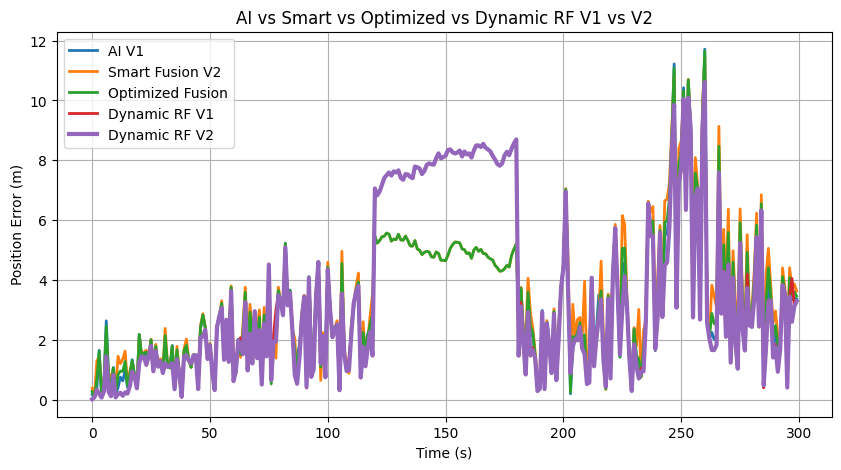

In [89]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_scenario_v2_m"], label="Smart Fusion V2", linewidth=2)
plt.plot(df["time_s"], df["error_fused_optimized_m"], label="Optimized Fusion", linewidth=2)
plt.plot(df["time_s"], df["error_fused_dynamic_m"], label="Dynamic RF V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_dynamic_v2_m"], label="Dynamic RF V2", linewidth=3)

plt.title("AI vs Smart vs Optimized vs Dynamic RF V1 vs V2")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [90]:
# Add temporal memory features
df["error_gnss_prev"] = df["error_gnss_m"].shift(1)
df["error_ins_prev"] = df["error_ins_m"].shift(1)

df["error_gnss_prev"] = df["error_gnss_prev"].bfill()
df["error_ins_prev"] = df["error_ins_prev"].bfill()

df[["error_gnss_m", "error_gnss_prev", "error_ins_m", "error_ins_prev"]].head()

,error_gnss_m,error_gnss_prev,error_ins_m,error_ins_prev
0,1.005913,1.005913,0.000000,0.000000
1,0.417603,1.005913,0.230589,0.000000
2,3.342753,0.417603,0.365021,0.230589
3,4.304933,3.342753,0.201153,0.365021
4,1.440787,4.304933,0.235851,0.201153


In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

dynamic_feature_cols_v3 = [
    "gnss_available",
    "predicted_alpha",
    "confidence_score",
    "rolling_gnss_std_x",
    "rolling_gnss_std_y",
    "gnss_ins_diff_x",
    "gnss_ins_diff_y",
    "gnss_ins_gap",
    "ins_speed_mps",
    "error_gnss_m",
    "error_ins_m",
    "error_gnss_prev",
    "error_ins_prev"
]

X_dyn_v3 = df[dynamic_feature_cols_v3]
y_dyn_v3 = df["oracle_alpha"]

X_train_dyn_v3, X_test_dyn_v3, y_train_dyn_v3, y_test_dyn_v3 = train_test_split(
    X_dyn_v3, y_dyn_v3, test_size=0.2, random_state=42
)

dynamic_model_v3 = RandomForestRegressor(
    n_estimators=500,
    max_depth=14,
    random_state=42
)

dynamic_model_v3.fit(X_train_dyn_v3, y_train_dyn_v3)
y_pred_dyn_v3 = dynamic_model_v3.predict(X_test_dyn_v3)

print("Temporal Dynamic Alpha RMSE:", np.sqrt(mean_squared_error(y_test_dyn_v3, y_pred_dyn_v3)))
print("Temporal Dynamic Alpha MAE:", mean_absolute_error(y_test_dyn_v3, y_pred_dyn_v3))
print("Temporal Dynamic Alpha R2:", r2_score(y_test_dyn_v3, y_pred_dyn_v3))

Temporal Dynamic Alpha RMSE: 0.2417681283386425
Temporal Dynamic Alpha MAE: 0.13876966666666654
Temporal Dynamic Alpha R2: 0.5870276727762108


In [92]:
df["predicted_alpha_dynamic_v3"] = dynamic_model_v3.predict(df[dynamic_feature_cols_v3])
df["predicted_alpha_dynamic_v3"] = df["predicted_alpha_dynamic_v3"].clip(0.0, 1.0)

fused_x_dynamic_v3 = []
fused_y_dynamic_v3 = []

for i in range(len(df)):
    a = df.loc[i, "predicted_alpha_dynamic_v3"]

    gnss_x = df.loc[i, "gnss_x_m"]
    gnss_y = df.loc[i, "gnss_y_m"]
    ins_x = df.loc[i, "ins_x_m"]
    ins_y = df.loc[i, "ins_y_m"]

    if np.isnan(gnss_x) or np.isnan(gnss_y):
        fused_x_dynamic_v3.append(ins_x)
        fused_y_dynamic_v3.append(ins_y)
    else:
        fused_x_dynamic_v3.append(a * gnss_x + (1 - a) * ins_x)
        fused_y_dynamic_v3.append(a * gnss_y + (1 - a) * ins_y)

df["fused_x_dynamic_v3_m"] = fused_x_dynamic_v3
df["fused_y_dynamic_v3_m"] = fused_y_dynamic_v3

df["error_fused_dynamic_v3_m"] = position_error(
    df["true_x_m"], df["true_y_m"],
    df["fused_x_dynamic_v3_m"], df["fused_y_dynamic_v3_m"]
)

In [93]:
metrics_dynamic_v3 = compute_navigation_metrics(
    df["error_fused_dynamic_v3_m"],
    df["fused_x_dynamic_v3_m"],
    df["fused_y_dynamic_v3_m"]
)

summary_dynamic_v3_df = pd.DataFrame({
    "GNSS_Only": metrics_gnss,
    "INS_Only": metrics_ins,
    "AI_V1": metrics_ai,
    "AI_Smart_Fusion_V2": metrics_scenario_v2,
    "AI_Optimized_Fusion": metrics_optimized,
    "AI_Dynamic_RF_V1": metrics_dynamic,
    "AI_Dynamic_RF_V2": metrics_dynamic_v2,
    "AI_Dynamic_RF_V3_Temporal": metrics_dynamic_v3
}).T

summary_dynamic_v3_df.round(4)

,RMSE_m,MAE_m,Availability
GNSS_Only,4.7516,3.8321,0.7967
INS_Only,7.4660,6.7584,1.0000
AI_V1,4.6922,3.7471,1.0000
AI_Smart_Fusion_V2,3.9957,3.3982,1.0000
AI_Optimized_Fusion,3.8467,3.2332,1.0000
AI_Dynamic_RF_V1,4.5705,3.5643,1.0000
AI_Dynamic_RF_V2,4.5592,3.5394,1.0000
AI_Dynamic_RF_V3_Temporal,4.5601,3.5399,1.0000


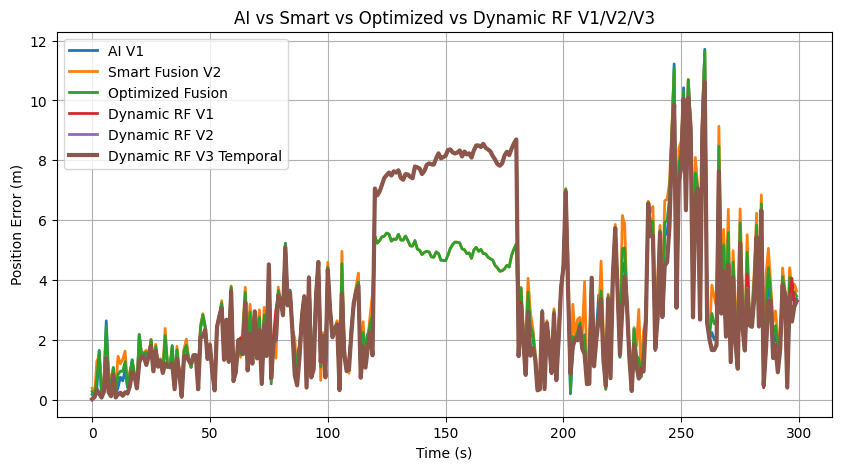

In [94]:
plt.figure(figsize=(10, 5))

plt.plot(df["time_s"], df["error_fused_ai_m"], label="AI V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_scenario_v2_m"], label="Smart Fusion V2", linewidth=2)
plt.plot(df["time_s"], df["error_fused_optimized_m"], label="Optimized Fusion", linewidth=2)
plt.plot(df["time_s"], df["error_fused_dynamic_m"], label="Dynamic RF V1", linewidth=2)
plt.plot(df["time_s"], df["error_fused_dynamic_v2_m"], label="Dynamic RF V2", linewidth=2)
plt.plot(df["time_s"], df["error_fused_dynamic_v3_m"], label="Dynamic RF V3 Temporal", linewidth=3)

plt.title("AI vs Smart vs Optimized vs Dynamic RF V1/V2/V3")
plt.xlabel("Time (s)")
plt.ylabel("Position Error (m)")
plt.legend()
plt.grid(True)
plt.show()

In [95]:
summary_dynamic_v3_df.to_csv("summary_dynamic_v3_temporal.csv")

print("Temporal dynamic fusion analysis saved successfully.")

Temporal dynamic fusion analysis saved successfully.
